In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)

In [4]:
df = pd.read_csv('../creditcard.csv')

x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Data loaded and preprocessed successfully!")
print("Training set size:", x_train.shape)
print("Test set size:", x_test.shape)

Data loaded and preprocessed successfully!
Training set size: (227845, 30)
Test set size: (56962, 30)


In [6]:
model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    n_jobs = -1,
    class_weight = 'balanced'
)

print('---/Training started/---')
model.fit(x_train, y_train)
print('Training completed!')

---/Training started/---
Training completed!


In [8]:
y_pred = model.predict(x_test)
y_pred_probab = model.predict_proba(x_test)[:, 1]

print("Predictions done!")
print("Total predictions made:", len(y_pred))

Predictions done!
Total predictions made: 56962


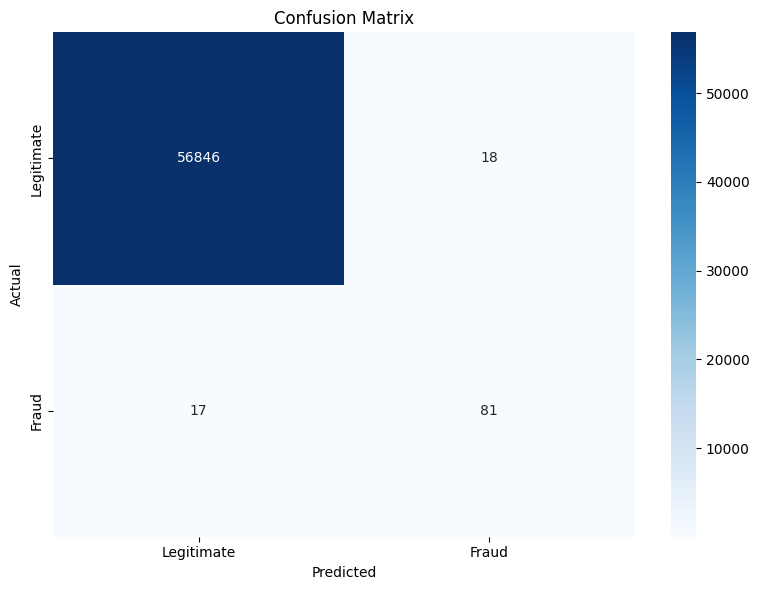


Confusion Matrix Numbers:
True Legitimate (correctly caught): 56846
False Fraud (legitimate wrongly flagged): 18
Missed Frauds (actual fraud missed): 17
True Fraud (correctly caught): 81


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels = ['Legitimate', 'Fraud'],
           yticklabels = ['Legitimate', 'Fraud'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png')
plt.show()

print("\nConfusion Matrix Numbers:")
print(f"True Legitimate (correctly caught): {cm[0][0]}")
print(f"False Fraud (legitimate wrongly flagged): {cm[0][1]}")
print(f"Missed Frauds (actual fraud missed): {cm[1][0]}")
print(f"True Fraud (correctly caught): {cm[1][1]}")